In [2]:
# Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp

### Phase 1: Linear algebra + statistics foundation
- These are the mathematical muscles ML uses constantly.

### Problem 1) Mean centering a dataset

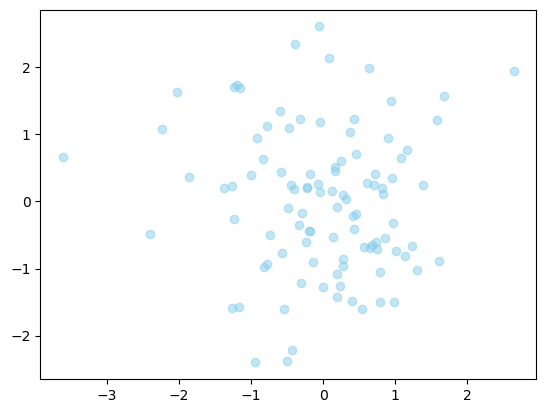

In [62]:
# Generate 100 random 2D points
X = np.random.normal(-1,1,(100,2))
mean = np.mean(X, axis=0)
X_centered = X - mean
plt.scatter(X_centered[:,0], X_centered[:,1], alpha = 0.5,color = 'skyblue')

### Problem 2: Covariance matrix

In [63]:
# computation of covariance metrix
C = X_centered.T@X_centered/(X_centered.shape[0]-1)
C_compare = np.cov(X_centered.T)
print(C)
print(C_compare)

[[ 0.92751264 -0.04497831]
 [-0.04497831  1.16080263]]
[[ 0.92751264 -0.04497831]
 [-0.04497831  1.16080263]]


### Problem 3: Eigen decomposition of covariance.

In [64]:
eigenvals, eigenvecs = np.linalg.eig(C)
print(eigenvals)

[0.91914122 1.16917405]


## Phase 2: Build PCA from scrach

### Problem 4: Project data onto principal axis

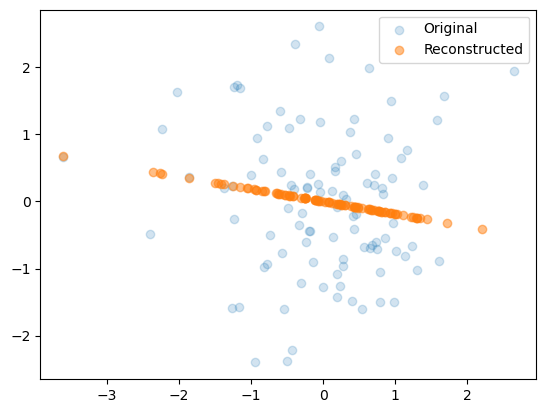

In [65]:
v1 = eigenvecs[0]
z = X_centered@v1
X_rec = z.reshape(-1,1)@v1.reshape(1,-1)
plt.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.2, label='Original')
plt.scatter(X_rec[:, 0], X_rec[:, 1], alpha=0.5, label='Reconstructed')
plt.legend()
plt.show()

### Problem 5: Learning SVD

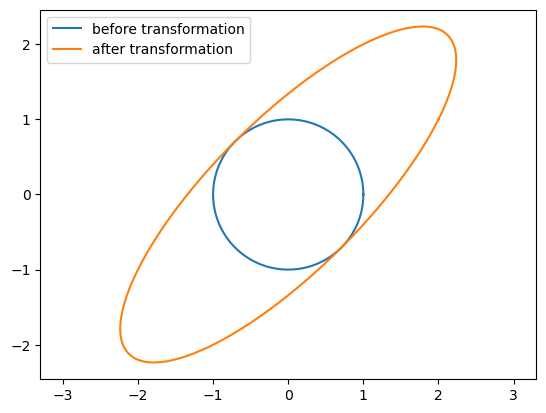

In [75]:
# Visualize matrix transformation (Unit circle transformation)
A = np.array([[2.0,1.0],
              [1.0,2.0]])

# Generate a unit circle of radius 1
r, theta = 1, np.pi*np.linspace(0,2,1000)
X = [r*np.cos(theta),r*np.sin(theta)]
X_prime = A@X
plt.plot(X[0], X[1], label = 'before transformation')
plt.plot(X_prime[0], X_prime[1], label = 'after transformation')
plt.axis('equal')
plt.legend()
plt.show()

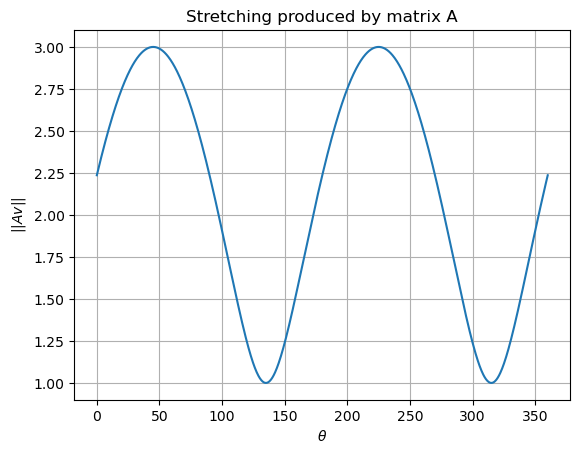

In [45]:
# Find the dorection of maximum straching
A = np.array([[2.0,1.0],
              [1.0,2.0]])
r, theta = 1, np.pi*np.linspace(0,2,1000)
# unit vectors on circle 
v = np.vstack((r*np.cos(theta),r*np.sin(theta)))
u = A@v
len = np.linalg.norm(u, axis = 0)

plt.plot(theta*180/np.pi,len)
plt.xlabel(r'$\theta$')
plt.ylabel(r'$||Av||$')
plt.title('Stretching produced by matrix A')
plt.grid()
plt.show()

In [48]:
# Manual calculation
A = np.array([[3,2,2],[2,-3,2]],dtype=float)
print('Given matrix =\n\n',A)
print(A.T@A)
# Find V and sigma
eigenvalues, eigenvactors = np.linalg.eig(A.T@A)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvactors = eigenvactors[:,idx]

# keep only nonzero eigenvalue
tol = 1.0e-10
mask = eigenvalues>tol

eigenvalues, eigenvactors = eigenvalues[mask], eigenvactors[:,mask]
sigma = np.sqrt(eigenvalues)
v = eigenvactors
u = (A@v)/sigma
print('\nSingular values = \n\n',np.diag(sigma))
print('\nRight singular vector:\n\n',v)
print('\nLeft singular vector:\n\n',u)
A = u@np.diag(sigma)@v.T
print('\nReconstructed A:\n\n',A)

Given matrix =

 [[ 3.  2.  2.]
 [ 2. -3.  2.]]
[[13.  0. 10.]
 [ 0. 13. -2.]
 [10. -2.  8.]]

Singular values = 

 [[4.58257569 0.        ]
 [0.         3.60555128]]

Right singular vector:

 [[-7.71516750e-01 -1.96116135e-01]
 [ 1.54303350e-01 -9.80580676e-01]
 [-6.17213400e-01  7.92653844e-17]]

Left singular vector:

 [[-0.70710678 -0.70710678]
 [-0.70710678  0.70710678]]

Reconstructed A:

 [[ 3.  2.  2.]
 [ 2. -3.  2.]]


In [49]:
u, s, vh = np.linalg.svd(A, full_matrices=False)
print('u =\n',u,'\nsigma = ',s,'\nv = \n',v)

u =
 [[-0.70710678 -0.70710678]
 [-0.70710678  0.70710678]] 
sigma =  [4.58257569 3.60555128] 
v = 
 [[-7.71516750e-01 -1.96116135e-01]
 [ 1.54303350e-01 -9.80580676e-01]
 [-6.17213400e-01  7.92653844e-17]]


In [55]:
# keep only largest singular value
A1 = sigma[0]*np.outer(u[:,0],v[:,0])
print(A1)

[[ 2.5 -0.5  2. ]
 [ 2.5 -0.5  2. ]]


### Problem 6: Image compression using PCA

In [29]:
# learning how to import image

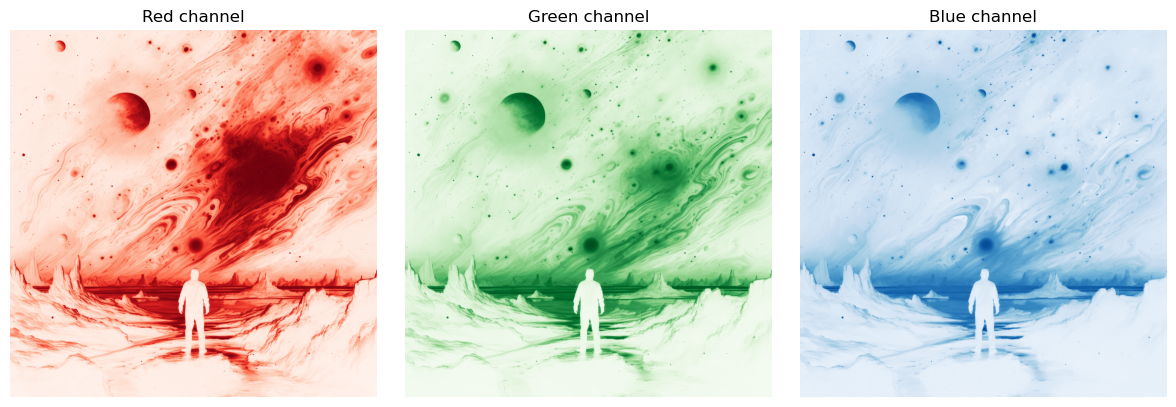

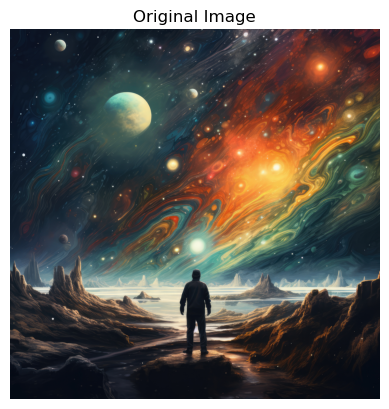

In [ ]:
# load image
img = plt.imread('img.jpg')

fig, ax = plt.subplots(1,3, figsize=(12,4))

# Red channel
ax[0].imshow(img[:,:,0], cmap='Reds')
ax[0].set_title('Red channel')
ax[0].axis('off')

# Green channel
ax[1].imshow(img[:,:,1], cmap='Greens')
ax[1].set_title('Green channel')
ax[1].axis('off')

# Blue channel
ax[2].imshow(img[:,:,2], cmap='Blues')
ax[2].set_title('Blue channel')
ax[2].axis('off')

plt.tight_layout()
plt.show()
plt.imshow(img)
plt.axis('off')
plt.title('Original Image')
plt.show()

4096 (4096, 4096) (4096, 4096)


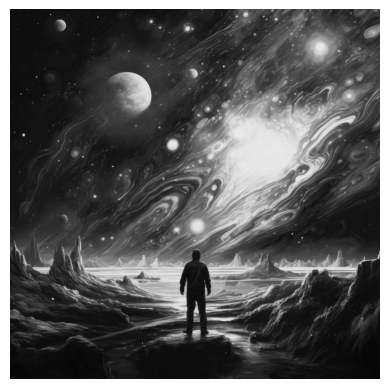

In [24]:
# Importing an image 
img = plt.imread('img.jpg')
img_gray = img[:,:,0]
u,sigma,v = np.linalg.svd(img_gray, full_matrices=False)
print(len(sigma),u.shape,v.shape)
k = int(20*len(sigma)/100)
u_k = u[:,:k] 
sigma_k = sigma[:k]
v_k = v[:k,:]
A_k = (u_k*sigma_k)@v_k
plt.imshow(A,cmap='gray')
plt.axis('off')
plt.show()

In [20]:
def svd(A):
    eig_val,eig_vac = np.linalg(A.T@A)
    idx = np.argsort(eig_val)
    eig_val_sorted = eig_val[idx]
    eig_vac_sorted = eig_vac[:,idx]
    mask = eig_val_sorted>1.0e-10
    eig_val_sorted = eig_val_sorted[mask]
    eig_vac_sorted = eig_vac_sorted[:,mask]

    sigma = np.sqrt(eig_val_sorted)
    v = eig_vac_sorted
    u = (A@v)/sigma
    return u,sigma,v

(np.float64(-0.5), np.float64(4095.5), np.float64(4095.5), np.float64(-0.5))

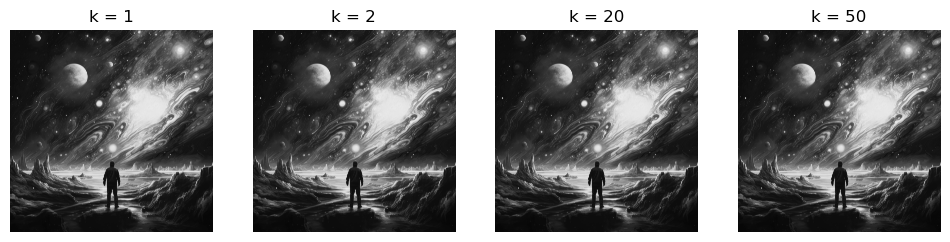

In [27]:
fig, ax = plt.subplots(1,4, figsize=(12,3))

k = int(1*len(sigma)/100)
u_k = u[:,:k] 
sigma_k = sigma[:k]
v_k = v[:k,:]
A = (u_k*sigma_k)@v_k

ax[0].imshow(A_k, cmap='gray')
ax[0].set_title('k = 1')
ax[0].axis('off')

k = int(2*len(sigma)/100)
u_k = u[:,:k] 
sigma_k = sigma[:k]
v_k = v[:k,:]
A = (u_k*sigma_k)@v_k

ax[1].imshow(A_k, cmap='gray')
ax[1].set_title('k = 2')
ax[1].axis('off')


k = int(20*len(sigma)/100)
u_k = u[:,:k] 
sigma_k = sigma[:k]
v_k = v[:k,:]
A = (u_k*sigma_k)@v_k

ax[2].imshow(A_k, cmap='gray')
ax[2].set_title('k = 20')
ax[2].axis('off')

k = int(50*len(sigma)/100)
u_k = u[:,:k] 
sigma_k = sigma[:k]
v_k = v[:k,:]
A = (u_k*sigma_k)@v_k

ax[3].imshow(A_k, cmap='gray')
ax[3].set_title('k = 50')
ax[3].axis('off')

## Phase 3: Optimization (heart of ML)

### Problem 7: Gradient descent for parabola

-1.9999999798043921
1.0000000000000004


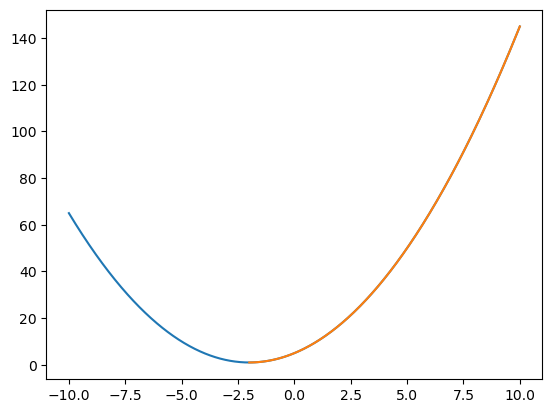

In [47]:
def f(x):
    return x**2 + 4*x + 5

def grad_f(x):
    return 2*x + 4

x = 10
eta = 0.01
steps = 1000
x_traj = []
f_x_traj = []
for i in range(steps):
    x_traj.append(x)
    f_x_traj.append(f(x))
    x -= eta*grad_f(x)
    
print(x)
print(f(x))

x_plot = np.linspace(-10,10,1000)
plt.plot(x_plot,f(x_plot))
plt.plot(x_traj, f_x_traj)


0.0025276015358185852
2.000019166349388


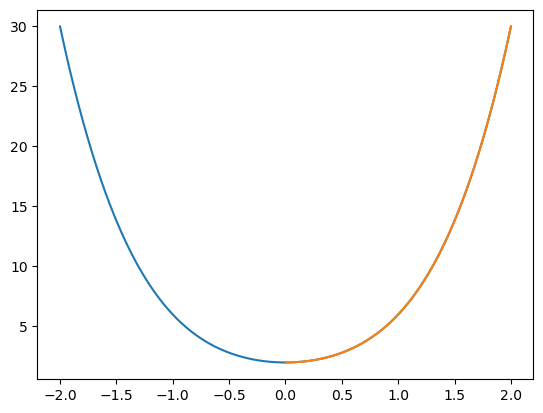

In [46]:
def f(x):
    return x**4 + 3*x**2 + 2

def grad_f(x):
    return 4*x**3 + 6*x

x = 2
eta = 0.001
steps = 1000
x_traj = []
f_x_traj = []
for i in range(steps):
    x_traj.append(x)
    f_x_traj.append(f(x))
    x -= eta*grad_f(x)
    
print(x)
print(f(x))

x_plot = np.linspace(-2,2,1000)
plt.plot(x_plot,f(x_plot))
plt.plot(x_traj, f_x_traj)


### Problem 8: Gradient descent in 2D

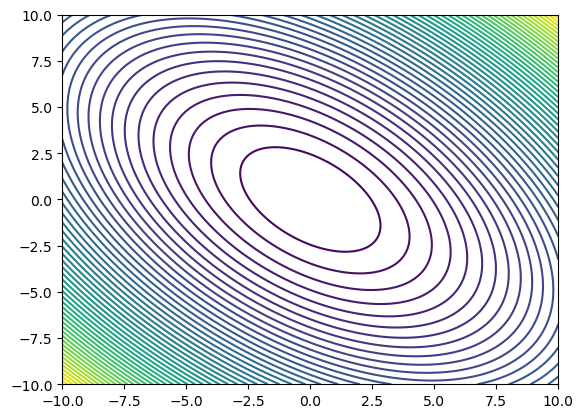

In [53]:
def f(x,y):
    return x**2 + y**2 + x*y

def f_grad(x,y):
    return 2*x+y,2*y+x

x = np.linspace(-10,10,1000)
y = np.linspace(-10,10,1000)
X, Y = np.meshgrid(x,y)
Z = f(X,Y)
plt.contour(X,Y,Z, levels=50)


In [67]:
# Initial points 
x0, y0 = 8, 7.5

eta, steps = 0.1, 50

x_traj, y_traj = [], []

# Gradient decent loop
for i in range(steps):
    x_traj.append(x0)
    y_traj.append(y0)

    dfdx,dfdy = f_grad(x0,y0)
    x0 -= eta*dfdx
    y0 -= eta*dfdy


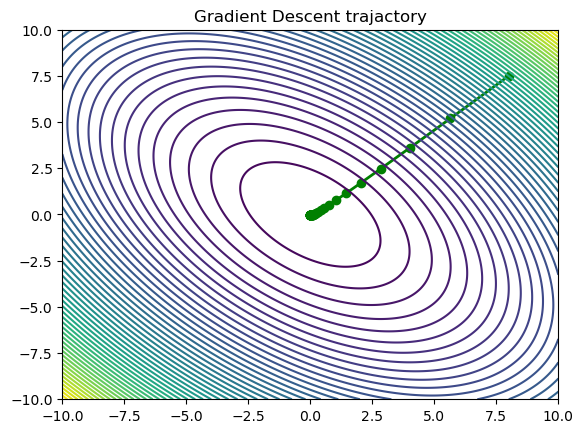

In [68]:
plt.plot(x_traj, y_traj,'go-', linewidth=2)
plt.contour(X,Y,Z, levels=50)
plt.title('Gradient Descent trajactory')
plt.show()

## Phase 4: Linear regression from scretch

### Problem 8: Closed-form regression

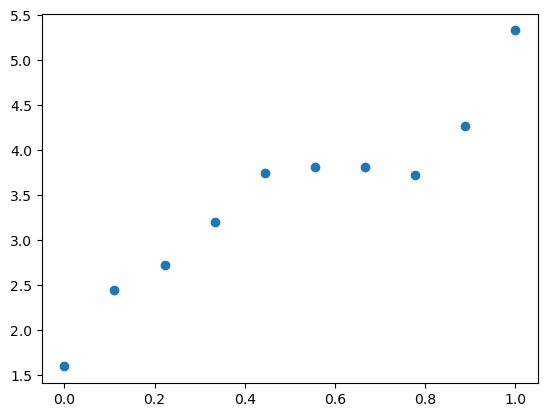

In [103]:
# noisy data 
epsilon = 0.3
def y(x):
    return 3*x + 2 + epsilon*np.random.normal(size=len(x))

x = np.linspace(0,1,10)
plt.scatter(x,y(x))

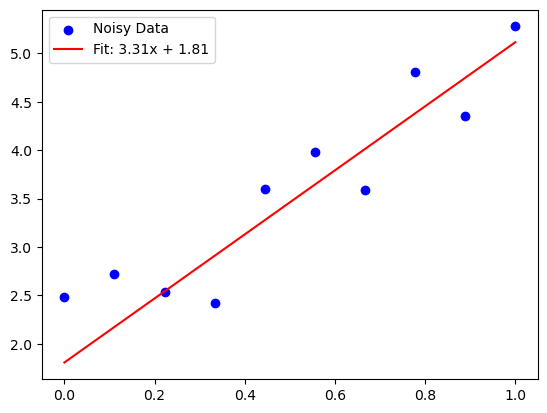

Calculated theta = [1.80849058 3.30595644]


In [159]:
X = np.ones((len(x),2))
X[:,1] = x
theta = (np.linalg.inv(X.T@X))@X.T@y(x)
y_model = X@theta
plt.scatter(x, y(x), color='blue', label='Noisy Data')
plt.plot(x, y_model, color='red', label=f'Fit: {theta[1]:.2f}x + {theta[0]:.2f}')
plt.legend()
plt.show()
print(f'Calculated theta = {theta}')